# Sponge damping taper comparison

Compares the west-boundary damping profile from `write_damping_tgb_tuv.py`'s original
`mult()` function against two zero-reaching alternatives:

- **Old**: the original tanh taper (`1 - tanh(...)`) -- asymptotic, never exactly 0
- **New**: the same tanh taper, min-max rescaled so it hits exactly 0 at the last point
- **Suggested**: a raised-cosine taper, which is exactly 0 by construction past `width`

Adjust `width`/`total_width` per boundary (west/east/north) at the bottom to match your
actual `w_nsponge`, `e_nsponge`, `n_nsponge` and computed `*_width_pts`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Taper functions

In [5]:
def mult_orig(width, total_width=100):
    """Original tanh taper from mult() in write_damping_tgb_tuv.py.
    Asymptotic: approaches but never reaches exactly 0."""
    i = np.arange(1, total_width + 1)
    return 1 - np.tanh((2 / np.e) * (i - 1) / (width - 1))


def mult_rescaled(width, total_width=100):
    """Same tanh shape as mult_orig, min-max rescaled to hit exactly 0
    at the last point and exactly 1 at the first. Minimal fix for mult() in the original script."""
    i = np.arange(1, total_width + 1)
    m = 1 - np.tanh((2 / np.e) * (i - 1) / (width - 1))
    return (m - m[-1]) / (m[0] - m[-1])


def mult_cosine(width, total_width=100):
    """Raised-cosine (Hann-type) taper. Reaches exactly 0 at i = width
    and stays flat 0 for the remainder of total_width"""
    i = np.arange(1, total_width + 1)
    x = np.clip((i - 1) / (width - 1), 0, 1)
    return 0.5* (1 + np.cos(np.pi * x))


## West boundary example (`width_pts=31`, `nsponge=120`)

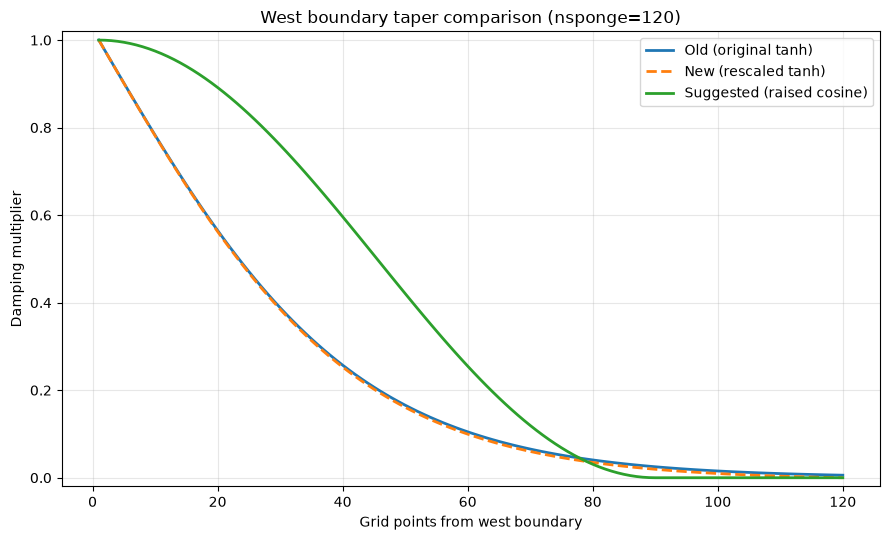

Old  last value: 0.005818070735947423
New  last value: 0.0
Cos  last value: 0.0


In [6]:
width_pts = 31      # decay width in grid points (tanh) -- from your w_width/dx conversion
nsponge   = 120     # sponge zone length in grid points -- your w_nsponge
cosine_width_pts = 90  # e.g. 3/4 of nsponge, leaving 1/4 as flat-zero padding

orig = mult_orig(width_pts, nsponge)
resc = mult_rescaled(width_pts, nsponge)
cos  = mult_cosine(cosine_width_pts, nsponge)

i = np.arange(1, nsponge + 1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(i, orig, label="Old (original tanh)", lw=2)
ax.plot(i, resc, label="New (rescaled tanh)", lw=2, ls="--")
ax.plot(i, cos,  label="Suggested (raised cosine)", lw=2)

ax.set_xlabel("Grid points from west boundary")
ax.set_ylabel("Damping multiplier")
ax.set_title(f"West boundary taper comparison (nsponge={nsponge})")
ax.set_ylim(-0.02, 1.02)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("Old  last value:", orig[-1])
print("New  last value:", resc[-1])
print("Cos  last value:", cos[-1])


## All three boundaries (west / east / north)

Set each boundary's `nsponge` and decay `width_pts` (computed from your physical
`w_width`/`e_width`/`n_width` and local grid spacing `dx`/`dy`, as in `write_damping`),
then compare old vs. new vs. suggested per boundary.

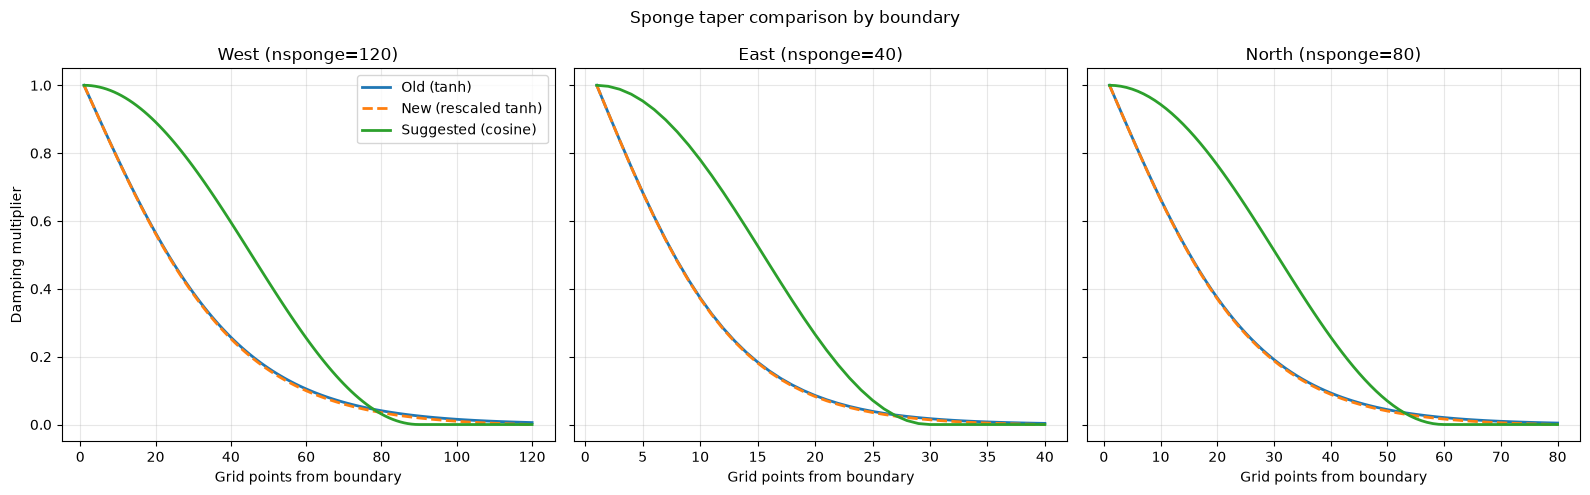

In [7]:
boundaries = {
    "West":  dict(nsponge=120, width_pts=31, cosine_width_pts=90),
    "East":  dict(nsponge=40,  width_pts=10, cosine_width_pts=30),
    "North": dict(nsponge=80,  width_pts=20, cosine_width_pts=60),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (name, p) in zip(axes, boundaries.items()):
    n = p["nsponge"]
    i = np.arange(1, n + 1)
    orig = mult_orig(p["width_pts"], n)
    resc = mult_rescaled(p["width_pts"], n)
    cos  = mult_cosine(p["cosine_width_pts"], n)

    ax.plot(i, orig, label="Old (tanh)", lw=2)
    ax.plot(i, resc, label="New (rescaled tanh)", lw=2, ls="--")
    ax.plot(i, cos,  label="Suggested (cosine)", lw=2)
    ax.set_title(f"{name} (nsponge={n})")
    ax.set_xlabel("Grid points from boundary")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Damping multiplier")
axes[0].legend()
fig.suptitle("Sponge taper comparison by boundary")
fig.tight_layout()
plt.show()
